# Naive Bayes implementation from scratch

### Imports

Loads the core libraries needed for the whole notebook — **pandas** for tabular data handling, **numpy** for the vectorized math behind the model, **matplotlib** for visualization, **train_test_split** for training, and **load_breast_cancer** from scikit-learn as a real-data source.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

### Loading Data

Loads the real Breast Cancer Wisconsin dataset using all 30 real tumor measurements, converts numeric diagnosis codes into readable labels, and splits into training/test sets.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame

X = df.drop(columns=["target"])
y = np.array(["malignant" if t == 0 else "benign" for t in df["target"].values])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

print(f"Training examples: {X_train.shape[0]}, Test examples: {X_test.shape[0]}, Features: {X_train.shape[1]}")

Training examples: 455, Test examples: 114, Features: 30


### Visualization

Plots two real features **(mean radius, mean texture)** colored by class, for a visual sense of separation.

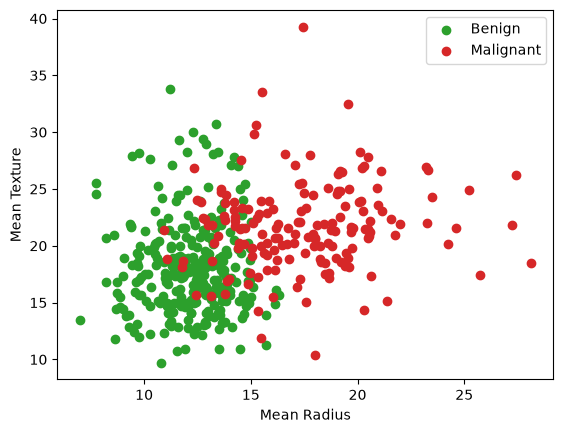

In [3]:
plt.scatter(X_train.loc[y_train == 'benign', 'mean radius'], X_train.loc[y_train == 'benign', 'mean texture'],
            color='tab:green', label='Benign')
plt.scatter(X_train.loc[y_train == 'malignant', 'mean radius'], X_train.loc[y_train == 'malignant', 'mean texture'],
            color='tab:red', label='Malignant')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.legend()
plt.show()

Shows mostly-separable class clustering, with malignant tumors trending toward higher radius and texture.

### Naive Bayes Class

Implements Gaussian Naive Bayes from scratch. **fit()** computes each class's prior probability and, for every one of the 30 features, that class's mean and standard deviation. **compute_log_likelihood()** treats each feature as an independent Gaussian and sums their log-probabilities to score how well a patient's measurements fit a given class.

In [4]:
class NaiveBayes:
    def fit(self, X_train, y_train):
        self.classes = np.unique(y_train)
        self.priors = [len(y_train[y_train == c]) / len(y_train) for c in self.classes]

        self.means = [X_train[y_train == c].mean() for c in self.classes]
        self.stds = [X_train[y_train == c].std() for c in self.classes]

    def compute_log_likelihood(self, row, class_idx):
        log_likelihood = 0
        for feature in row.index:
            mean = self.means[class_idx][feature]
            std = self.stds[class_idx][feature]
            log_pdf = -np.log(np.sqrt(2 * np.pi) * std) - ((row[feature] - mean) ** 2) / (2 * std ** 2)
            log_likelihood += log_pdf
        return log_likelihood

    def predict(self, X):
        y_pred = []
        for _, row in X.iterrows():
            posteriors = []
            for i in range(len(self.classes)):
                log_posterior = self.compute_log_likelihood(row, i) + np.log(self.priors[i])
                posteriors.append(log_posterior)

            y_pred.append(self.classes[np.argmax(posteriors)])

        return np.array(y_pred)

### Training & Predicting

Fits the model on the training data, then predicts each test patient's class by comparing log-posterior scores across both classes and picking the higher one.

In [5]:
nb = NaiveBayes()
nb.fit(X_train, y_train)

predictions = nb.predict(X_test)
accuracy = np.mean(predictions == y_test) * 100
print(f"Test accuracy: {accuracy:.2f}%")

Test accuracy: 93.86%


**93.86% test accuracy**, correctly classifying 107 of 114 real, previously unseen patients.

### Sklearn Validation

Fits scikit-learn's **GaussianNB** on the identical data as an independent correctness check.


In [6]:
from sklearn.naive_bayes import GaussianNB

sk_nb = GaussianNB()
sk_nb.fit(X_train, y_train)
sk_accuracy = sk_nb.score(X_test, y_test) * 100

print(f"From scratch: {accuracy:.2f}%")
print(f"sklearn:      {sk_accuracy:.2f}%")

From scratch: 93.86%
sklearn:      93.86%


**93.86%** for both. This makes sense given Naive Bayes has a closed-form fit: directly computed statistics, no optimization process to converge differently.